In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("../outputs/gender_output_2025-10-07 19:53:20.141369_ContrastiveLoss_gru_catboost/out_*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [4]:
len(df_all)

7200

In [5]:
print(df_all)

      batch_size  learning_rate  split_count  cnt_min  cnt_max  embedding_dim  \
0             16          0.001            3       10      100             32   
1             16          0.001            3       10      100             32   
2             16          0.001            3       10      100             32   
3             16          0.001            3       10      100             32   
4             16          0.001            3       10      100             32   
...          ...            ...          ...      ...      ...            ...   
7195         128          0.001            3       10      100             32   
7196         128          0.001            3       10      100             32   
7197         128          0.001            3       10      100             32   
7198         128          0.001            3       10      100             32   
7199         128          0.001            3       10      100             32   

      category_embedding_di

In [6]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [8]:
df_all = df_all.set_index('checkpoint')

In [29]:
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign 
            })

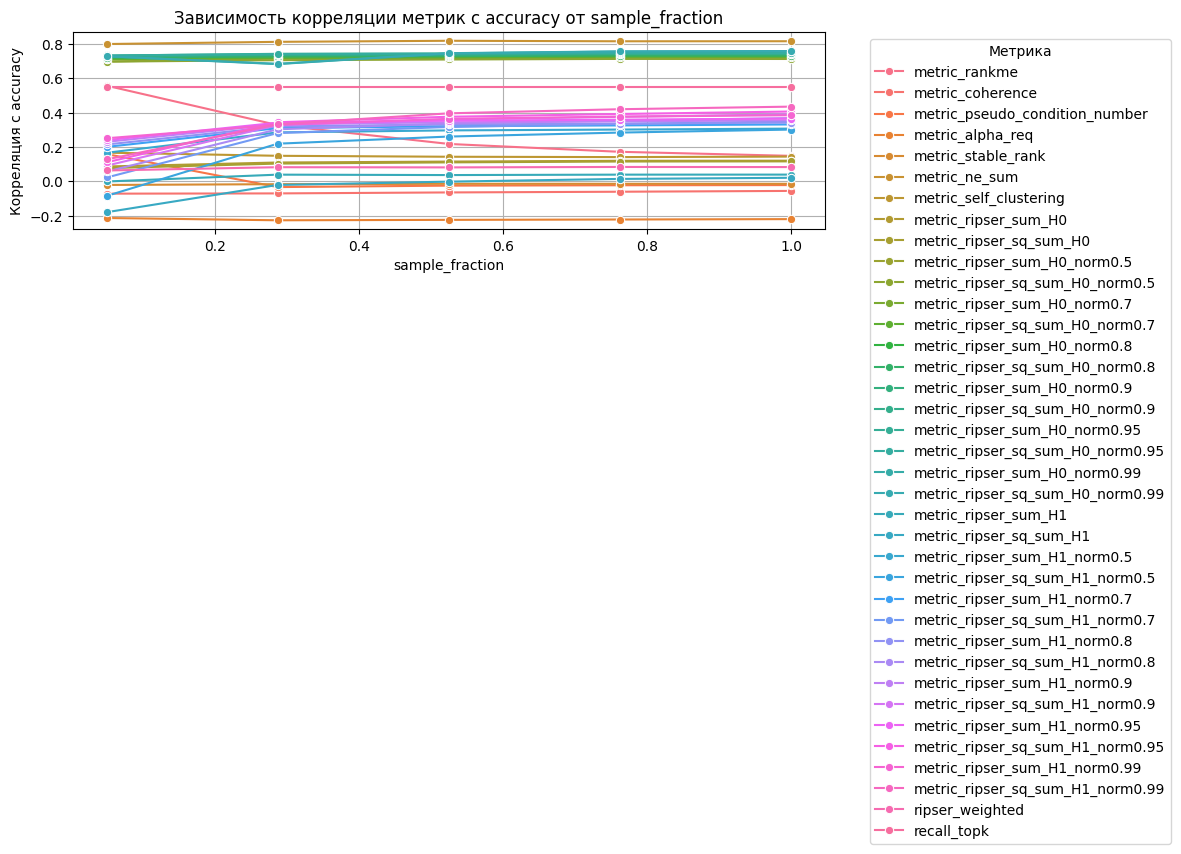

In [30]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [31]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.556892
1               0.05                  metric_coherence    -0.072326
2               0.05    metric_pseudo_condition_number     0.158017
3               0.05                  metric_alpha_req    -0.214384
4               0.05                metric_stable_rank    -0.021491
..               ...                               ...          ...
180             1.00  metric_ripser_sq_sum_H1_norm0.95     0.406710
181             1.00     metric_ripser_sum_H1_norm0.99     0.385079
182             1.00  metric_ripser_sq_sum_H1_norm0.99     0.435222
183             1.00                   ripser_weighted     0.082713
184             1.00                       recall_topk     0.551316

[185 rows x 3 columns]


In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.813176
metric_ripser_sum_H0_norm0.95       0.743699
metric_ripser_sq_sum_H0_norm0.95    0.743346
metric_ripser_sum_H0_norm0.9        0.739021
metric_ripser_sq_sum_H0_norm0.9     0.737807
metric_ripser_sq_sum_H0_norm0.99    0.735492
metric_ripser_sum_H0_norm0.99       0.734493
metric_ripser_sum_H0_norm0.8        0.731257
metric_ripser_sq_sum_H0_norm0.8     0.728858
metric_ripser_sum_H0_norm0.7        0.724387
metric_ripser_sq_sum_H0_norm0.7     0.721042
metric_ripser_sum_H0_norm0.5        0.712924
metric_ripser_sq_sum_H0_norm0.5     0.708127
recall_topk                         0.551316
metric_ripser_sq_sum_H1_norm0.99    0.342315
metric_ripser_sum_H1_norm0.99       0.341322
metric_ripser_sum_H1_norm0.95       0.331880
metric_ripser_sq_sum_H1_norm0.95    0.326028
metric_ripser_sum_H1_norm0.9        0.322205
metric_ripser_sq_sum_H1_norm0.9     0.309066
metric_ripser_sum_H1_norm0.8        0.308843
metric_ripser_sum_H1_norm0.7        0.297641
met

In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.816629
metric_ripser_sq_sum_H0_norm0.99    0.759379
metric_ripser_sum_H0_norm0.99       0.758513
metric_ripser_sum_H0_norm0.95       0.748437
metric_ripser_sq_sum_H0_norm0.95    0.748220
metric_ripser_sum_H0_norm0.9        0.742743
metric_ripser_sq_sum_H0_norm0.9     0.741845
metric_ripser_sum_H0_norm0.8        0.734715
metric_ripser_sq_sum_H0_norm0.8     0.732854
metric_ripser_sum_H0_norm0.7        0.728186
metric_ripser_sq_sum_H0_norm0.7     0.725532
metric_ripser_sum_H0_norm0.5        0.717145
metric_ripser_sq_sum_H0_norm0.5     0.713162
recall_topk                         0.551316
metric_ripser_sq_sum_H1_norm0.99    0.435222
metric_ripser_sq_sum_H1_norm0.95    0.406710
metric_ripser_sq_sum_H1_norm0.9     0.390551
metric_ripser_sum_H1_norm0.99       0.385079
metric_ripser_sum_H1_norm0.95       0.365533
metric_ripser_sum_H1_norm0.9        0.355363
metric_ripser_sum_H1_norm0.8        0.342059
metric_ripser_sum_H1_norm0.7        0.331315
met

In [13]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.806763
metric_ripser_sum_H0_norm0.95       0.738187
metric_ripser_sq_sum_H0_norm0.95    0.737819
metric_ripser_sum_H0_norm0.9        0.734612
metric_ripser_sq_sum_H0_norm0.9     0.733315
metric_ripser_sum_H0_norm0.8        0.726903
metric_ripser_sq_sum_H0_norm0.8     0.724333
metric_ripser_sum_H0_norm0.7        0.719319
metric_ripser_sq_sum_H0_norm0.7     0.715758
metric_ripser_sum_H0_norm0.5        0.706755
metric_ripser_sq_sum_H0_norm0.99    0.706747
metric_ripser_sum_H0_norm0.99       0.705889
metric_ripser_sq_sum_H0_norm0.5     0.701876
recall_topk                         0.551316
metric_rankme                       0.442299
metric_ripser_sum_H1_norm0.95       0.290714
metric_ripser_sum_H1_norm0.99       0.290242
metric_ripser_sum_H1_norm0.9        0.281301
metric_ripser_sum_H1_norm0.8        0.267288
metric_ripser_sum_H1_norm0.7        0.255067
metric_ripser_sq_sum_H1_norm0.99    0.230027
metric_ripser_sq_sum_H1_norm0.95    0.227487
met

# Overall Spearmann Corr

In [33]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": corr #* sign
            })
            


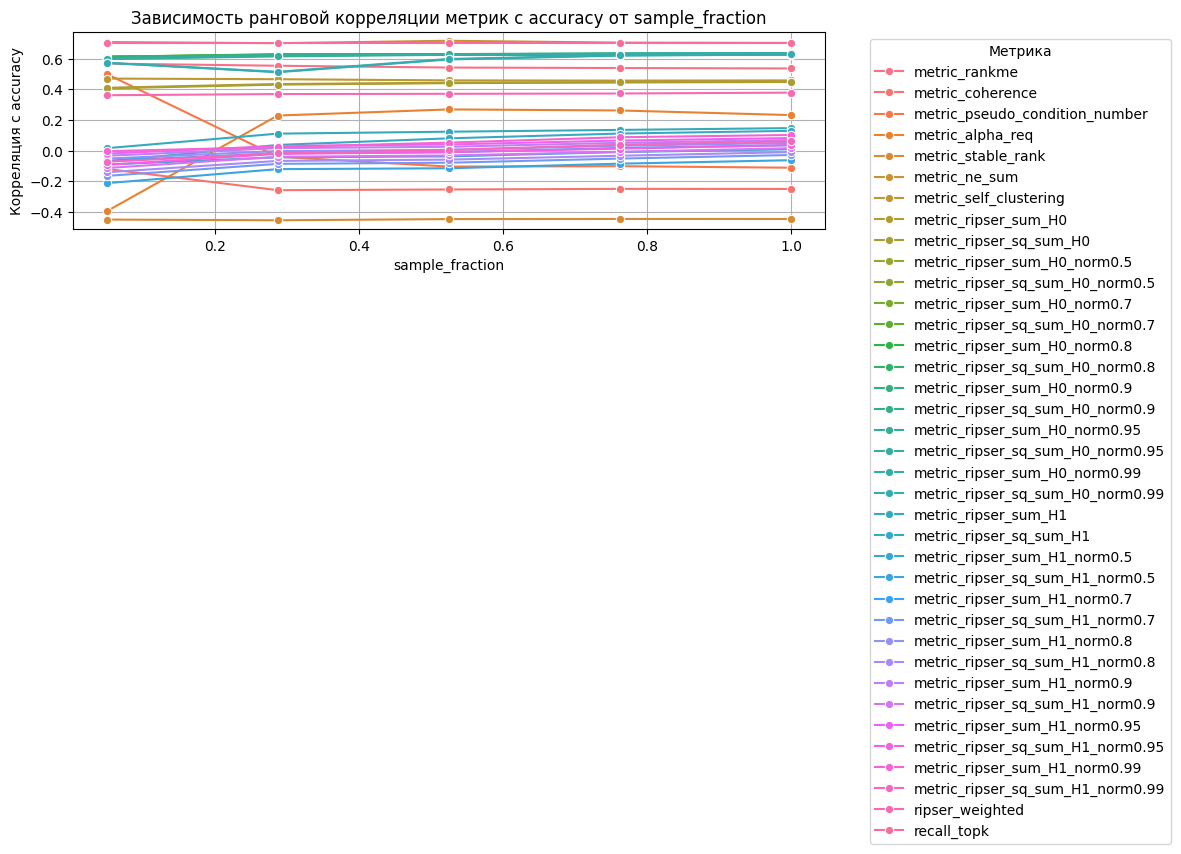

In [34]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [35]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7041410915573783,
 'metric_ne_sum': 0.7020553575290956,
 'metric_ripser_sq_sum_H0_norm0.9': 0.634385879457199,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6340723838802127,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6322656390791414,
 'metric_ripser_sum_H0_norm0.9': 0.6321790690973751,
 'metric_ripser_sum_H0_norm0.95': 0.6320817844192395,
 'metric_ripser_sum_H0_norm0.8': 0.6306571260117599,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6303428125066844,
 'metric_ripser_sum_H0_norm0.7': 0.6291623036800601,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6275528014315727,
 'metric_ripser_sq_sum_H0_norm0.5': 0.625982222871371,
 'metric_ripser_sum_H0_norm0.99': 0.6257918331557843,
 'metric_ripser_sum_H0_norm0.5': 0.6257100033345218,
 'metric_rankme': 0.5355023067052117,
 'metric_self_clustering': 0.4574569907784685,
 'metric_ripser_sum_H0': 0.44942413172224543,
 'metric_ripser_sq_sum_H0': 0.4470638067491645,
 'ripser_weighted': 0.37771505192817745,
 'metric_alpha_req': 0.23119982415905832,
 'metric

In [36]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7060280087042348,
 'recall_topk': 0.7041410915573783,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6262403090525778,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6253273020428656,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6250202925979631,
 'metric_ripser_sum_H0_norm0.8': 0.6242891087635393,
 'metric_ripser_sum_H0_norm0.7': 0.623884727927608,
 'metric_ripser_sum_H0_norm0.9': 0.6226749659585412,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6220430397420877,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6202350200974633,
 'metric_ripser_sum_H0_norm0.5': 0.6200487883466276,
 'metric_ripser_sum_H0_norm0.95': 0.6197823982236704,
 'metric_ripser_sq_sum_H0_norm0.99': 0.586331228998924,
 'metric_ripser_sum_H0_norm0.99': 0.5845091117575746,
 'metric_rankme': 0.5470792001569504,
 'metric_self_clustering': 0.46118367972145247,
 'metric_ripser_sum_H0': 0.4362657459092715,
 'metric_ripser_sq_sum_H0': 0.4331524507307571,
 'ripser_weighted': 0.36976224459592943,
 'metric_alpha_req': 0.1186590633002301,
 'metric_

In [18]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'recall_topk': 0.7041410915573783,
 'metric_ne_sum': 0.703972996520354,
 'metric_ripser_sq_sum_H0_norm0.7': 0.619791772581397,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6192654462436299,
 'metric_ripser_sum_H0_norm0.7': 0.6183961510141414,
 'metric_ripser_sum_H0_norm0.8': 0.6173787160577996,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6141816423595485,
 'metric_ripser_sum_H0_norm0.5': 0.6133414415714089,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6126622351359448,
 'metric_ripser_sum_H0_norm0.9': 0.6121063272304341,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6079916859513665,
 'metric_ripser_sum_H0_norm0.95': 0.6059193663653777,
 'metric_rankme': 0.5601879557655082,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5425854565085325,
 'metric_ripser_sum_H0_norm0.99': 0.5415574213836767,
 'metric_self_clustering': 0.4672891117325334,
 'metric_stable_rank': 0.45288446189131554,
 'metric_ripser_sum_H0': 0.4215951336048779,
 'metric_ripser_sq_sum_H0': 0.4176457220981509,
 'ripser_weighted': 0.36454558094282674,
 'metri

# Correlation for best checkpoint choice

In [16]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


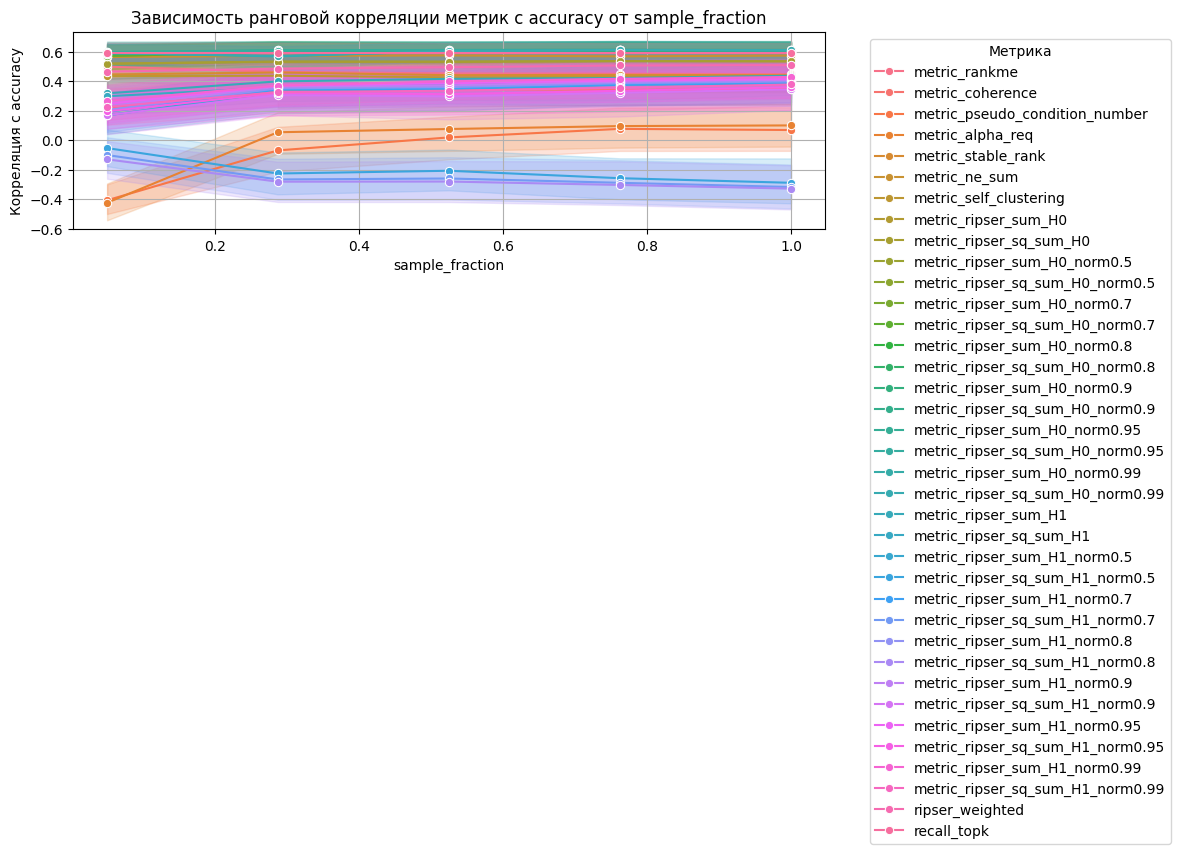

In [20]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.6133412749577698,
 'metric_ripser_sum_H0_norm0.99': 0.6125510253133678,
 'metric_ripser_sum_H0_norm0.95': 0.6112336501383389,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6107849457156599,
 'metric_ripser_sum_H0_norm0.9': 0.6093262996107428,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6078358305617816,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6075604222705414,
 'metric_ripser_sum_H0_norm0.5': 0.603317964304787,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6015572620410274,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6006801310344099,
 'metric_ripser_sum_H0_norm0.8': 0.6004599418775481,
 'metric_ripser_sum_H0_norm0.7': 0.5973298079438611,
 'recall_topk': 0.5968576144875763,
 'metric_ne_sum': 0.5760492909140951,
 'metric_ripser_sq_sum_H0': 0.5373240290799564,
 'metric_ripser_sum_H0': 0.5364901045316968,
 'ripser_weighted': 0.5109806250457233,
 'metric_rankme': 0.4496327149412126,
 'metric_stable_rank': 0.44236079564324654,
 'metric_ripser_sum_H1': 0.4384813836676792,
 'metric_

In [22]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.95': 0.6103213538805126,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6096872168891765,
 'metric_ripser_sum_H0_norm0.9': 0.6057755235696585,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6052524249098442,
 'metric_ripser_sq_sum_H0_norm0.5': 0.601979021647374,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5997941006046188,
 'metric_ripser_sum_H0_norm0.99': 0.5990930463069124,
 'metric_ripser_sum_H0_norm0.5': 0.5990522695741979,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5988618935478092,
 'metric_ripser_sum_H0_norm0.8': 0.5987814235994774,
 'recall_topk': 0.5968576144875763,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5935729654186329,
 'metric_ripser_sum_H0_norm0.7': 0.5924551201526268,
 'metric_ne_sum': 0.5727633838784445,
 'metric_ripser_sq_sum_H0': 0.5333899746174717,
 'metric_ripser_sum_H0': 0.5325582419320873,
 'ripser_weighted': 0.4940672685899849,
 'metric_rankme': 0.46443531717925957,
 'metric_stable_rank': 0.44756593498368197,
 'metric_self_clustering': 0.4331320476310762,
 'metr

In [23]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.95': 0.6062010705882146,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6045761324740333,
 'metric_ripser_sum_H0_norm0.9': 0.6002826593385394,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5994351960037178,
 'recall_topk': 0.5968576144875763,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5955514283303446,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5952509042939421,
 'metric_ripser_sum_H0_norm0.8': 0.5952156659558452,
 'metric_ripser_sum_H0_norm0.5': 0.592333430099927,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5859692221676142,
 'metric_ripser_sum_H0_norm0.7': 0.5856363717766061,
 'metric_ripser_sq_sum_H0_norm0.99': 0.5825620349757665,
 'metric_ripser_sum_H0_norm0.99': 0.5818317924658691,
 'metric_ne_sum': 0.5699942575208492,
 'metric_ripser_sq_sum_H0': 0.5280574718783637,
 'metric_ripser_sum_H0': 0.5273024294205213,
 'metric_rankme': 0.48293343774927433,
 'ripser_weighted': 0.47685299146593707,
 'metric_stable_rank': 0.4541455308726793,
 'metric_self_clustering': 0.4375009333338597,
 'metr

# Linear correlation of epoch choice

In [24]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

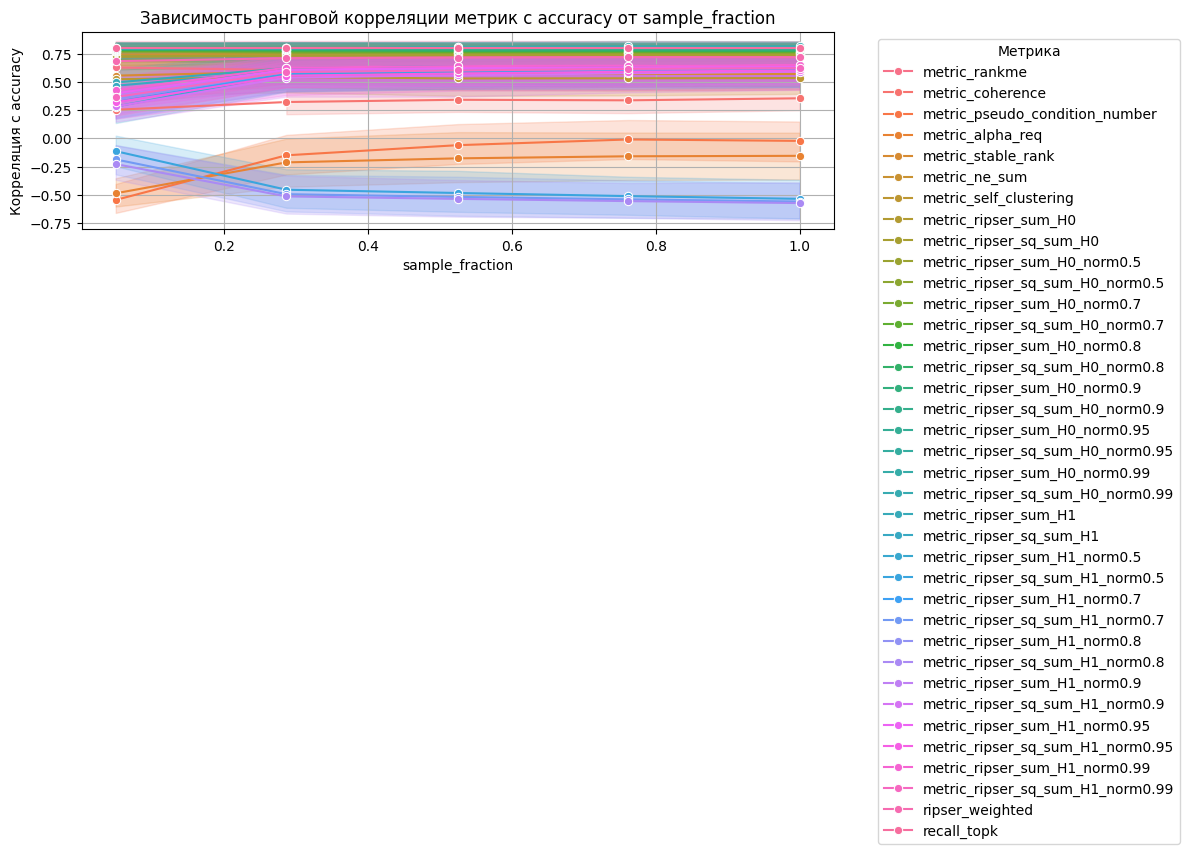

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [26]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sq_sum_H0_norm0.99    0.812878
metric_ripser_sum_H0_norm0.99       0.811422
recall_topk                         0.801024
metric_ripser_sq_sum_H0_norm0.95    0.795148
metric_ripser_sum_H0_norm0.95       0.794738
metric_ripser_sq_sum_H0_norm0.9     0.786732
metric_ripser_sum_H0_norm0.9        0.786724
metric_ripser_sum_H0_norm0.8        0.775293
metric_ripser_sq_sum_H0_norm0.8     0.774827
metric_ripser_sum_H0_norm0.7        0.765634
metric_ripser_sq_sum_H0_norm0.7     0.764777
metric_ripser_sum_H0_norm0.5        0.756441
metric_ripser_sq_sum_H0_norm0.5     0.755167
metric_ne_sum                       0.752552
metric_ripser_sq_sum_H0             0.736611
metric_ripser_sum_H0                0.733389
ripser_weighted                     0.717995
metric_ripser_sum_H1_norm0.99       0.648973
metric_ripser_sum_H1                0.647574
metric_ripser_sum_H1_norm0.95       0.636301
metric_ripser_sq_sum_H1             0.630421
metric_ripser_sum_H1_norm0.9        0.630140
met

In [27]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
recall_topk                         0.801024
metric_ripser_sum_H0_norm0.95       0.797109
metric_ripser_sq_sum_H0_norm0.95    0.796422
metric_ripser_sum_H0_norm0.9        0.791954
metric_ripser_sq_sum_H0_norm0.99    0.791888
metric_ripser_sum_H0_norm0.99       0.791076
metric_ripser_sq_sum_H0_norm0.9     0.790217
metric_ripser_sum_H0_norm0.8        0.783382
metric_ripser_sq_sum_H0_norm0.8     0.780224
metric_ripser_sum_H0_norm0.7        0.775384
metric_ripser_sq_sum_H0_norm0.7     0.771338
metric_ripser_sum_H0_norm0.5        0.766869
metric_ripser_sq_sum_H0_norm0.5     0.762693
metric_ne_sum                       0.744319
metric_ripser_sq_sum_H0             0.728088
metric_ripser_sum_H0                0.725977
ripser_weighted                     0.695334
metric_rankme                       0.615033
metric_stable_rank                  0.571515
metric_ripser_sum_H1                0.557580
metric_self_clustering              0.532142
metric_ripser_sq_sum_H1             0.530961
met

# Score of best epoch

In [28]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

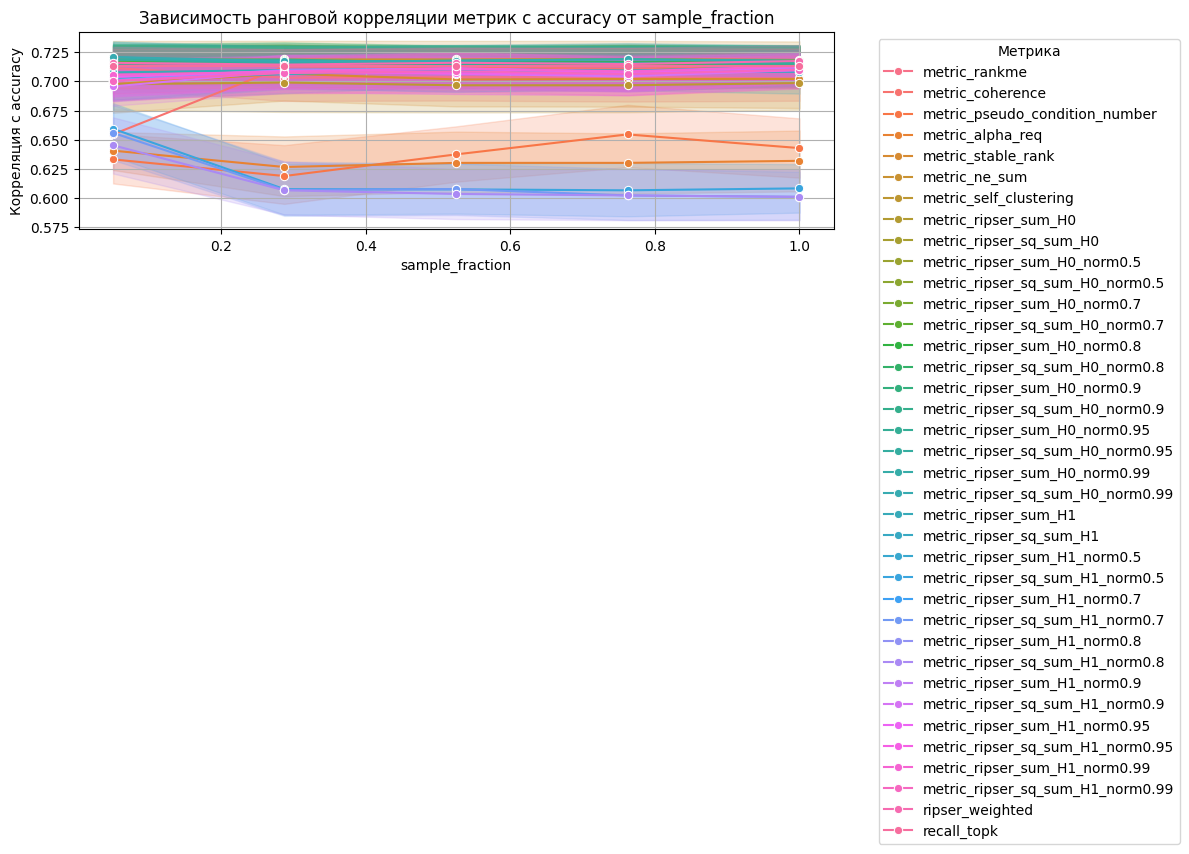

In [29]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [30]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.71895,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7184815,
 'metric_ripser_sum_H0_norm0.99': 0.7183305,
 'metric_ripser_sum_H0_norm0.95': 0.7169495,
 'metric_ripser_sum_H0_norm0.8': 0.7166245000000001,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7163755,
 'metric_ripser_sum_H0_norm0.7': 0.7161839999999999,
 'metric_ripser_sum_H0_norm0.9': 0.71601,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7158955,
 'metric_ripser_sq_sum_H0_norm0.5': 0.715846,
 'ripser_weighted': 0.715807,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7155974999999999,
 'metric_ripser_sum_H0_norm0.5': 0.7155244999999999,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7154564999999999,
 'metric_ripser_sum_H0': 0.7153019999999999,
 'metric_ripser_sq_sum_H0': 0.7151115,
 'recall_topk': 0.71296,
 'metric_coherence': 0.7120883561643836,
 'metric_ripser_sum_H1': 0.7101165,
 'metric_ripser_sum_H1_norm0.99': 0.7094015,
 'metric_ripser_sum_H1_norm0.95': 0.7088485,
 'metric_ripser_sum_H1_norm0.9': 0.7088065,
 'metric_ripser_sum_H1_norm0.8'

In [31]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7185125,
 'metric_ripser_sum_H0_norm0.99': 0.71791,
 'ripser_weighted': 0.7175675,
 'metric_ripser_sq_sum_H0_norm0.99': 0.717395,
 'metric_ripser_sum_H0_norm0.9': 0.71627,
 'metric_ripser_sum_H0_norm0.8': 0.7162275,
 'metric_ripser_sum_H0_norm0.7': 0.71618,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7158599999999999,
 'metric_ripser_sq_sum_H0_norm0.9': 0.71546,
 'metric_ripser_sq_sum_H0_norm0.95': 0.71543,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7153775,
 'metric_ripser_sum_H0_norm0.95': 0.7153575,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7151124999999999,
 'metric_ripser_sum_H0_norm0.5': 0.7142725,
 'metric_ripser_sq_sum_H0': 0.713785,
 'metric_ripser_sum_H0': 0.713785,
 'metric_coherence': 0.7137702702702703,
 'metric_ripser_sum_H1_norm0.99': 0.7132275,
 'metric_ripser_sum_H1': 0.7130650000000001,
 'recall_topk': 0.71296,
 'metric_ripser_sum_H1_norm0.95': 0.7125725,
 'metric_ripser_sum_H1_norm0.9': 0.71193,
 'metric_ripser_sum_H1_norm0.7': 0.71193,
 'metric_ripser_sum_H1_no

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.71919125,
 'metric_ne_sum': 0.7189875,
 'metric_ripser_sum_H0_norm0.95': 0.7187175,
 'metric_ripser_sum_H0_norm0.99': 0.71834875,
 'metric_ripser_sq_sum_H0_norm0.95': 0.71751375,
 'metric_ripser_sum_H0': 0.71721125,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7169512499999999,
 'metric_ripser_sum_H0_norm0.8': 0.71686625,
 'metric_ripser_sq_sum_H0': 0.716735,
 'metric_ripser_sum_H0_norm0.7': 0.71641625,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7160825,
 'metric_ripser_sum_H0_norm0.5': 0.71597,
 'metric_ripser_sq_sum_H0_norm0.5': 0.71585,
 'metric_ripser_sq_sum_H0_norm0.8': 0.71577875,
 'metric_ripser_sum_H0_norm0.9': 0.7157375,
 'ripser_weighted': 0.71523,
 'recall_topk': 0.71296,
 'metric_coherence': 0.7112888888888889,
 'metric_ripser_sum_H1': 0.708805,
 'metric_rankme': 0.7073825,
 'metric_ripser_sum_H1_norm0.99': 0.70697875,
 'metric_ripser_sum_H1_norm0.9': 0.70646125,
 'metric_ripser_sum_H1_norm0.95': 0.706415,
 'metric_ripser_sum_H1_norm0.8': 0.705498

In [33]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [34]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme nan
metric_rankme nan
metric_coherence nan
metric_coherence nan
metric_pseudo_condition_number nan
metric_pseudo_condition_number nan
metric_alpha_req nan
metric_alpha_req nan
metric_stable_rank nan
metric_stable_rank nan
metric_ne_sum nan
metric_ne_sum nan
metric_self_clustering nan
metric_self_clustering nan
metric_ripser_sum_H0 nan
metric_ripser_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sq_sum_H0 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sq_sum_H0_norm0.5 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sq_sum_H0_norm0.7 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sq_sum_H0_norm0.8 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_sq_sum_H0_norm0.9 nan
metric_ripser_su

# Corr of best hyperparam by metric

In [ ]:
print(list(df_all.columns))

In [17]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 'mcc_code_in', 
             'term_id_in', 
             'tr_type_in', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

/tmp/ipykernel_1340651/2097346452.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1340651/2097346452.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_1340651/2097346452.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


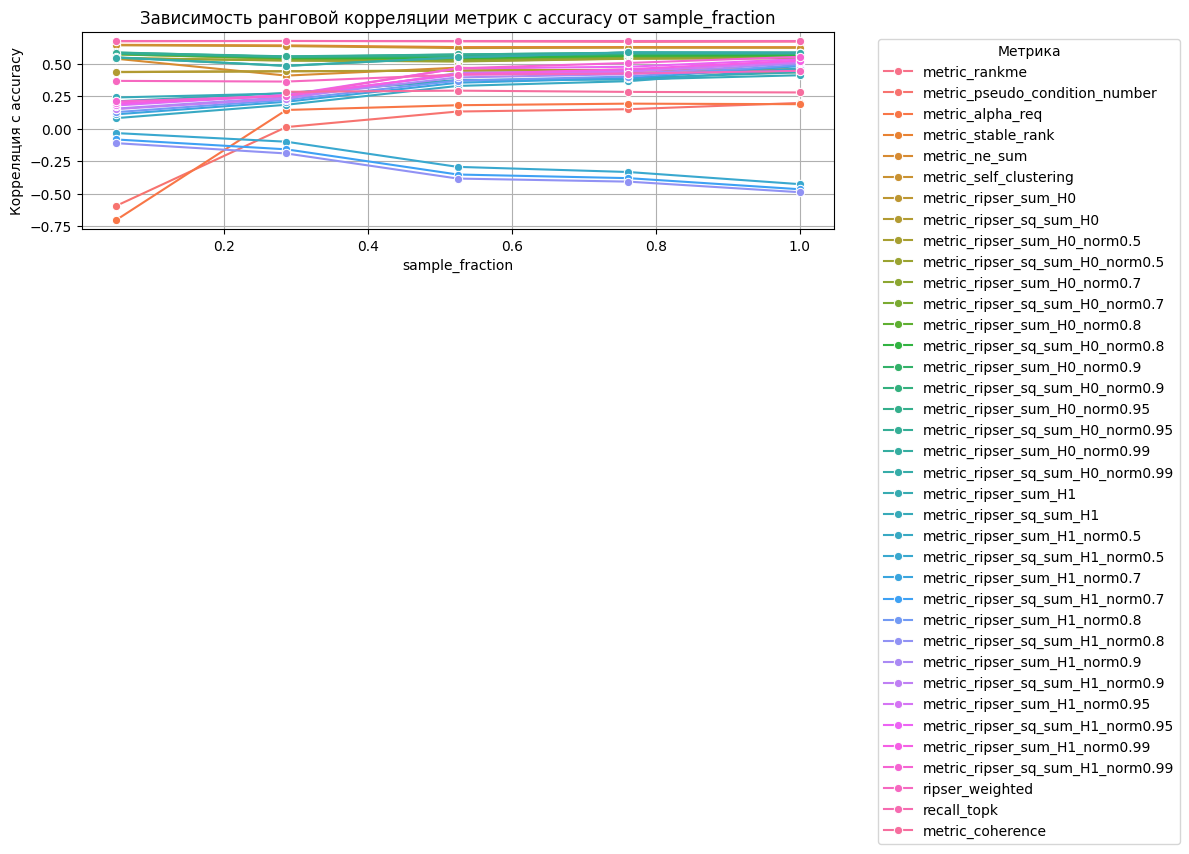

learning_rate


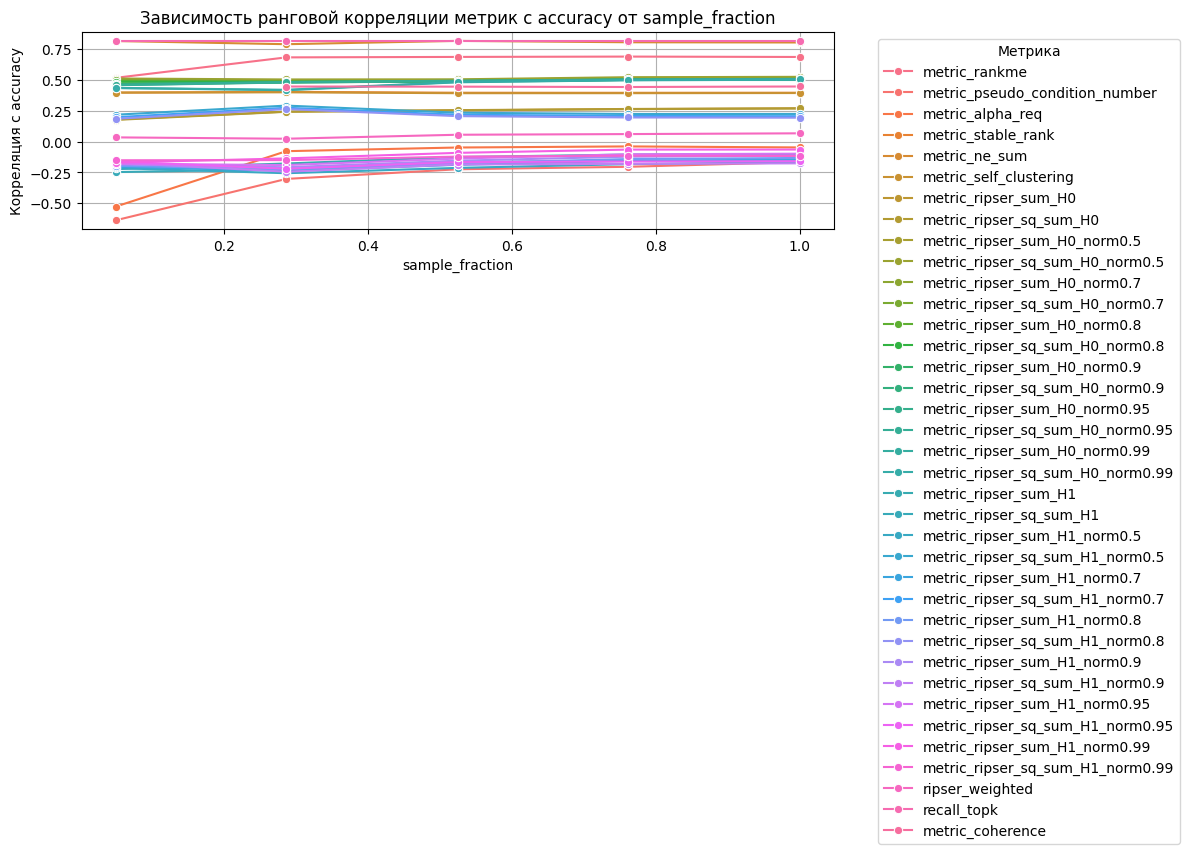

split_count


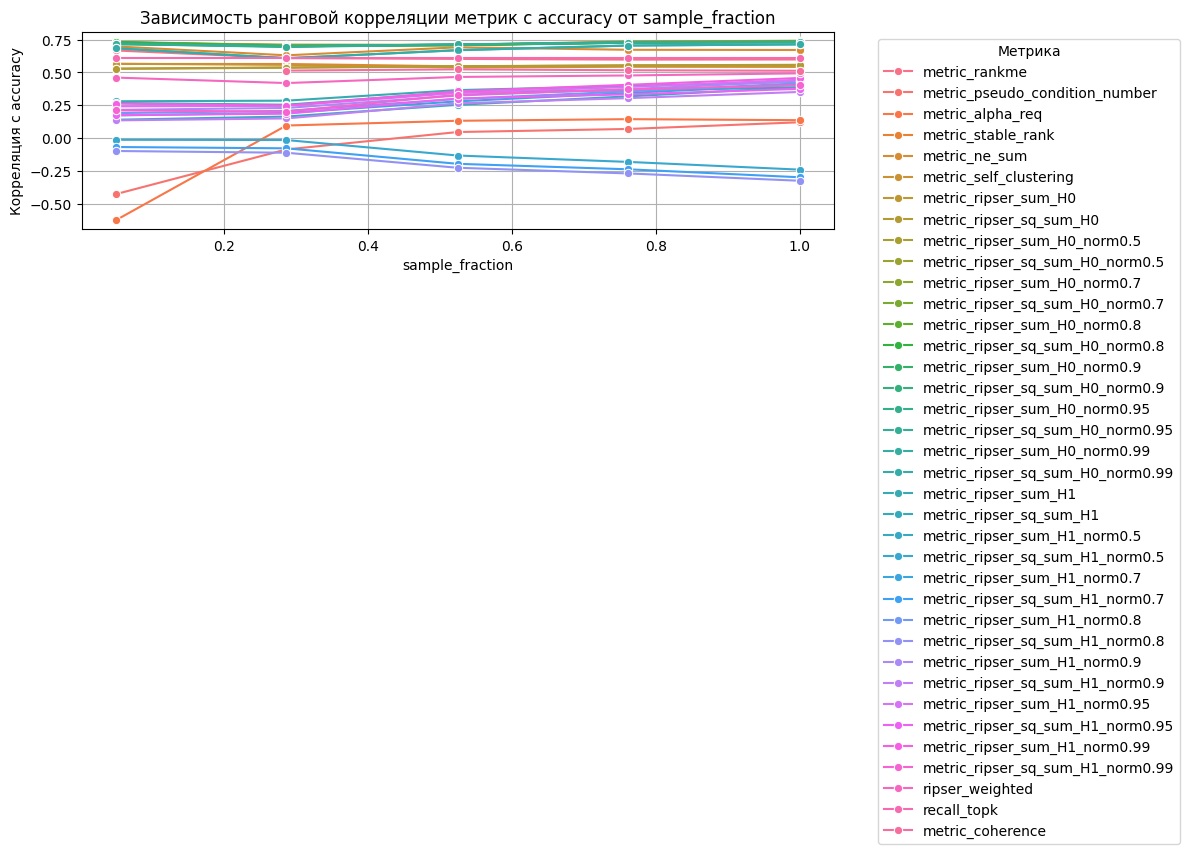

cnt_min


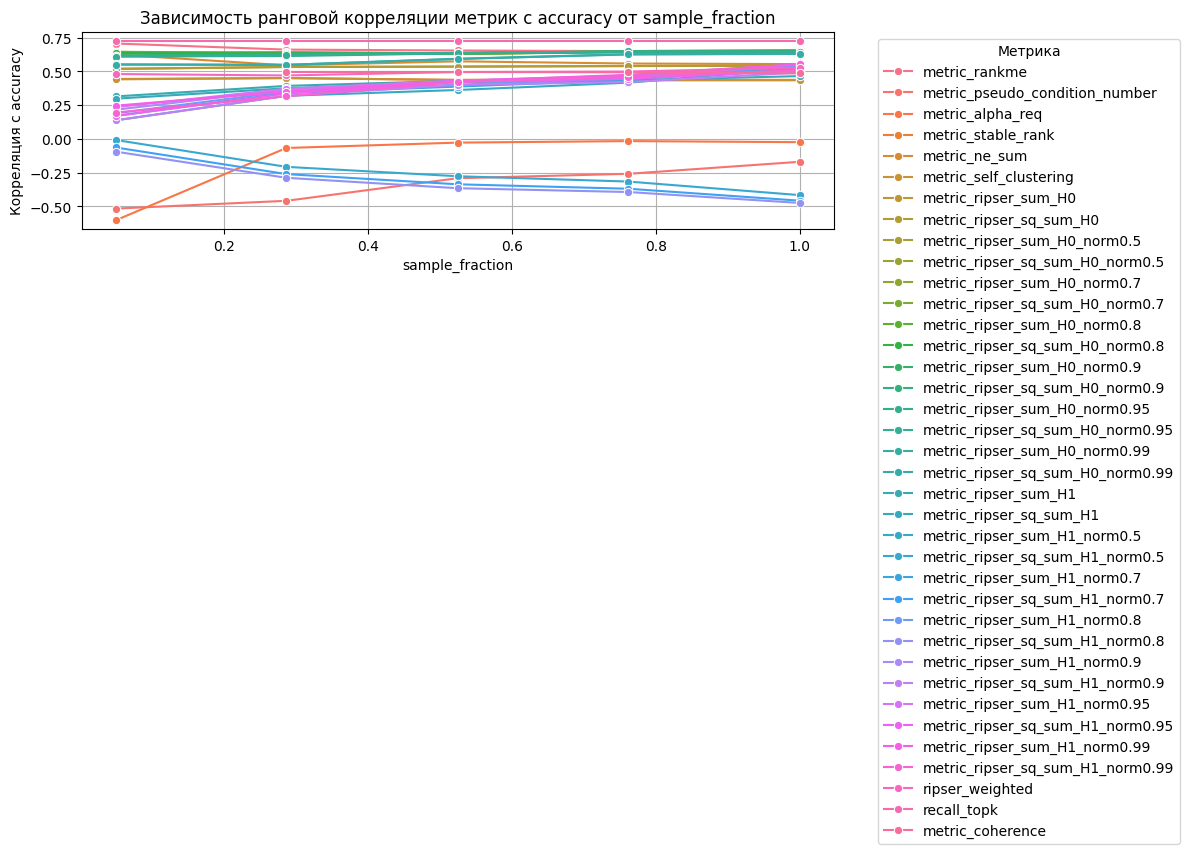

cnt_max


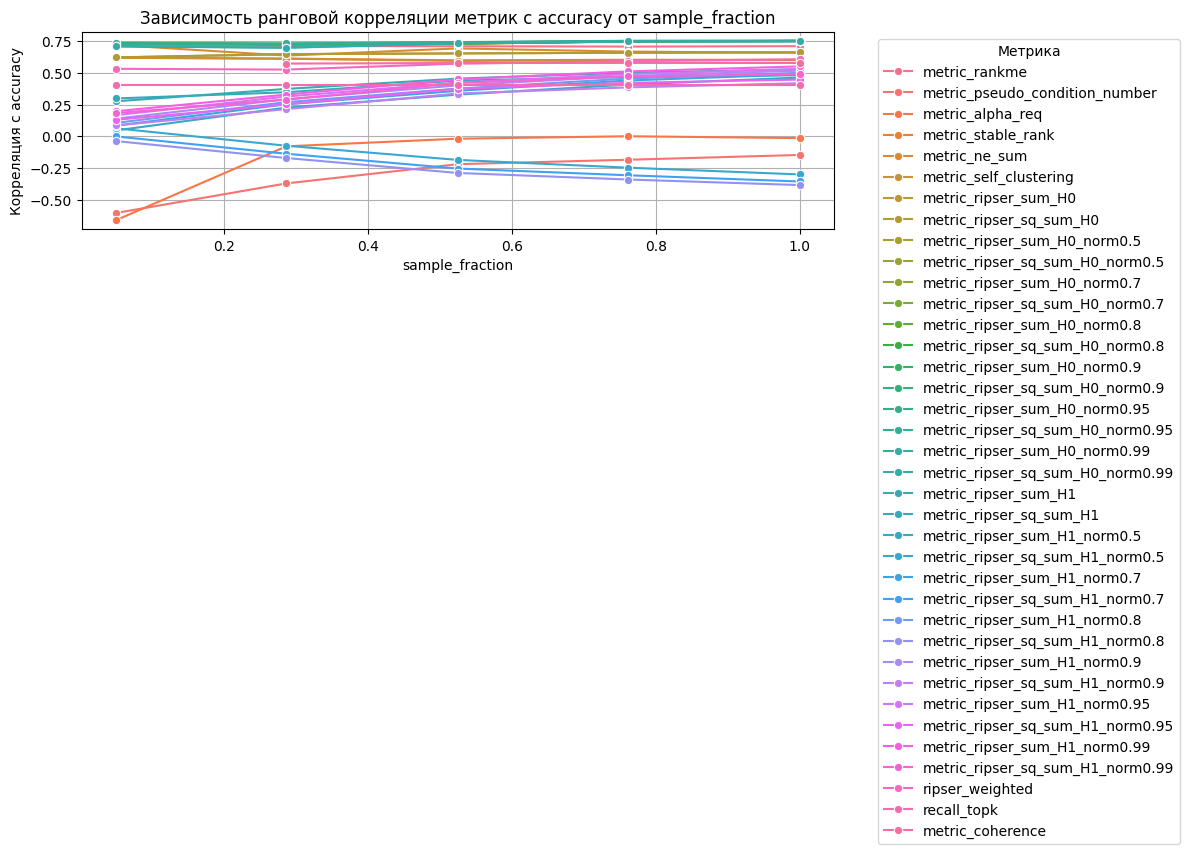

embedding_dim


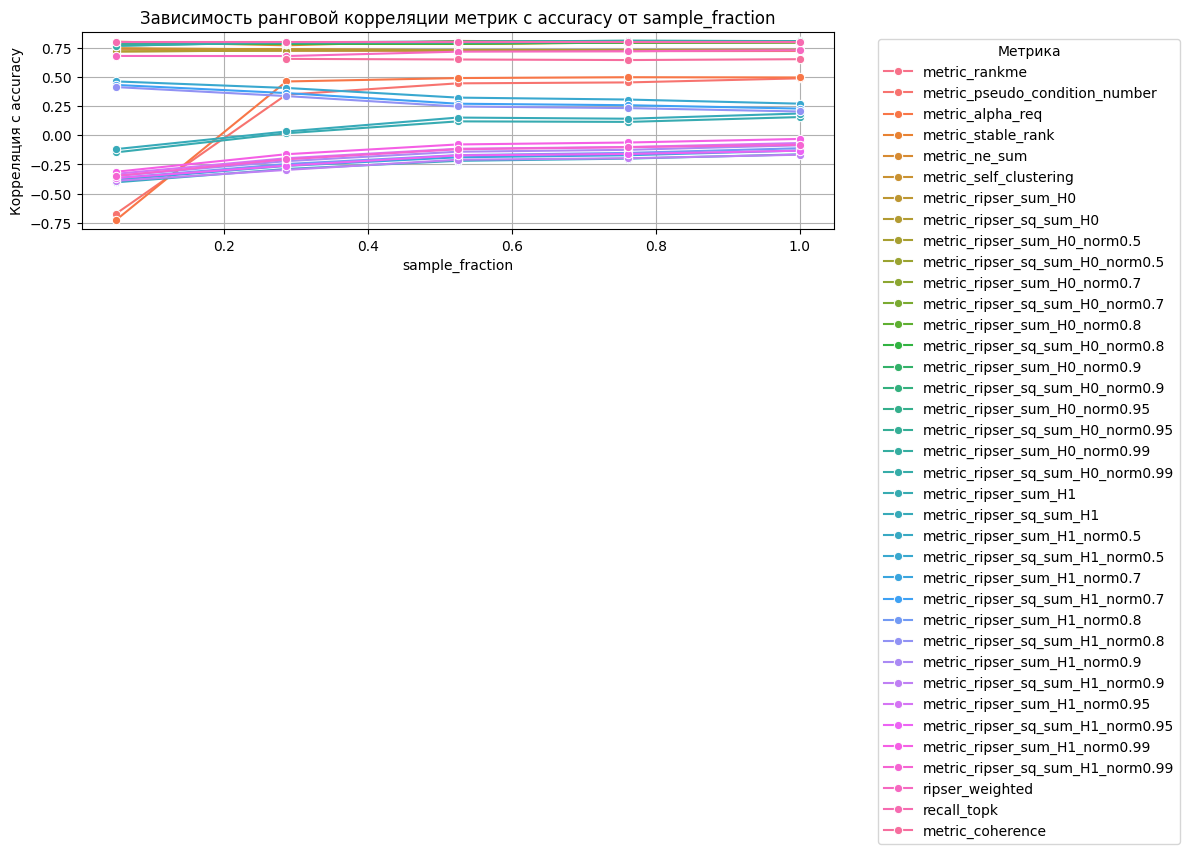

category_embedding_dim


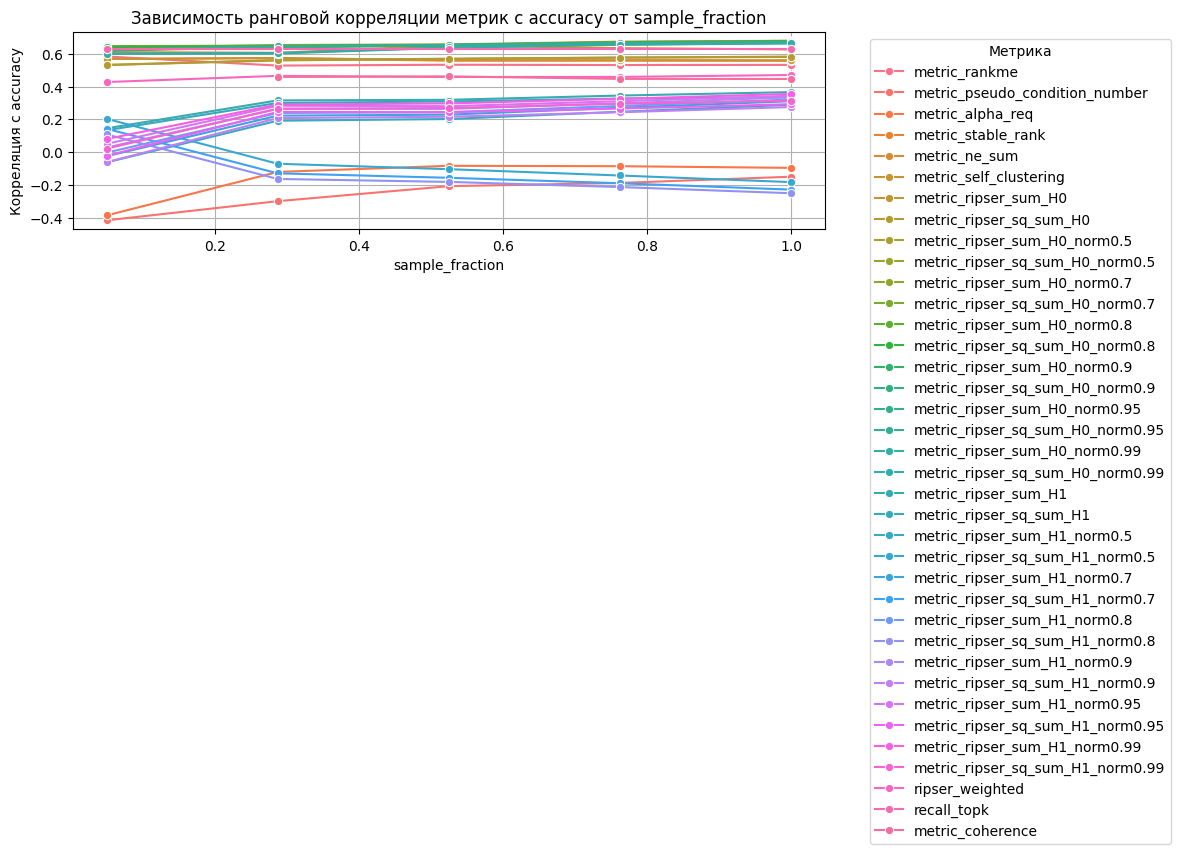

hidden_size


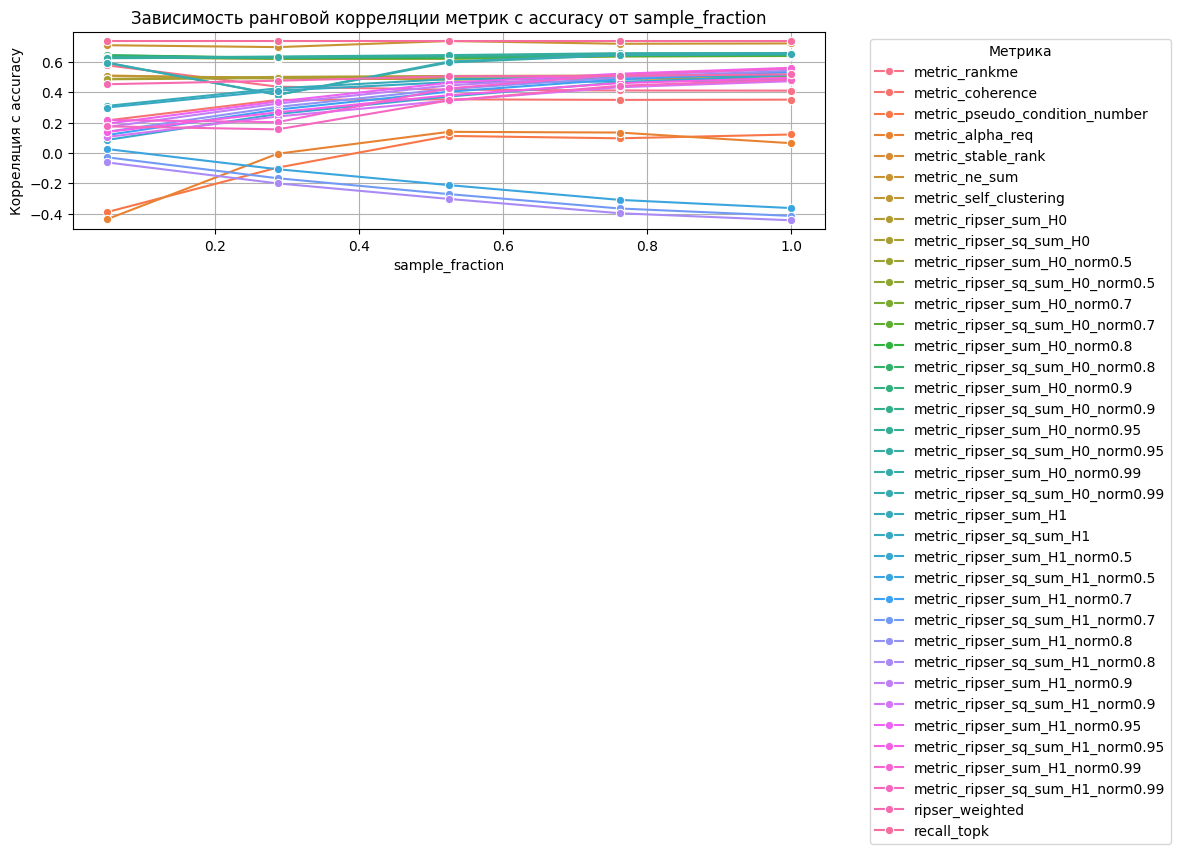

mcc_code_in


ValueError: Could not interpret value `sample_fraction` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [18]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [23]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print(corr_df)
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
        print(mean_corr)

batch_size
     sample_fraction                            metric      corr
0               0.05                     metric_rankme  0.673435
1               0.05    metric_pseudo_condition_number -0.595391
2               0.05                  metric_alpha_req -0.704876
3               0.05                metric_stable_rank  0.645990
4               0.05                     metric_ne_sum  0.539260
..               ...                               ...       ...
179             1.00  metric_ripser_sq_sum_H1_norm0.95  0.535996
180             1.00     metric_ripser_sum_H1_norm0.99  0.524691
181             1.00  metric_ripser_sq_sum_H1_norm0.99  0.553580
182             1.00                   ripser_weighted  0.445847
183             1.00                       recall_topk  0.677232

[184 rows x 3 columns]
metric
recall_topk                         0.677232
metric_rankme                       0.674658
metric_stable_rank                  0.643864
metric_self_clustering              0.63928

# Score of best hyperparams by metric

In [ ]:
from collections import defaultdict
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 'mcc_code_in', 
             'term_id_in', 
             'tr_type_in', 
             'loss', 
             'rnn_encoder_type']

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

batch_size


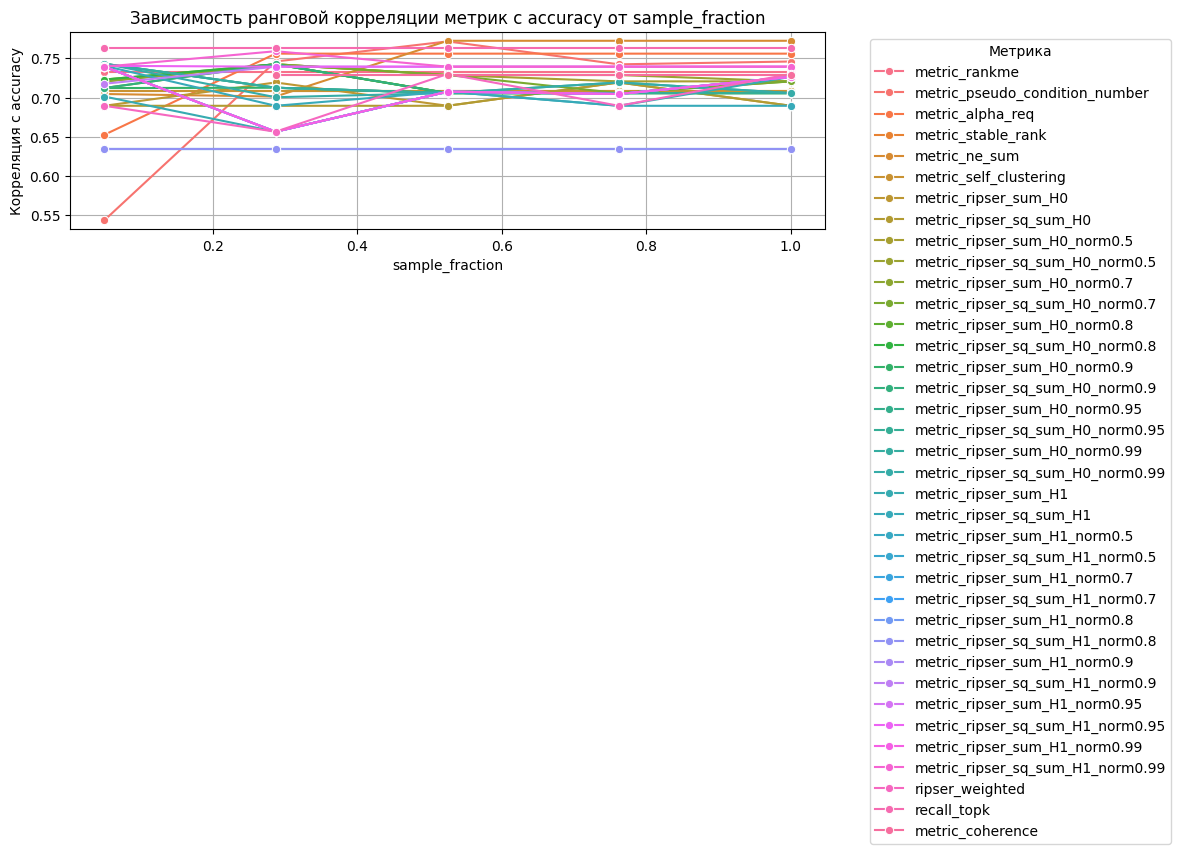

learning_rate


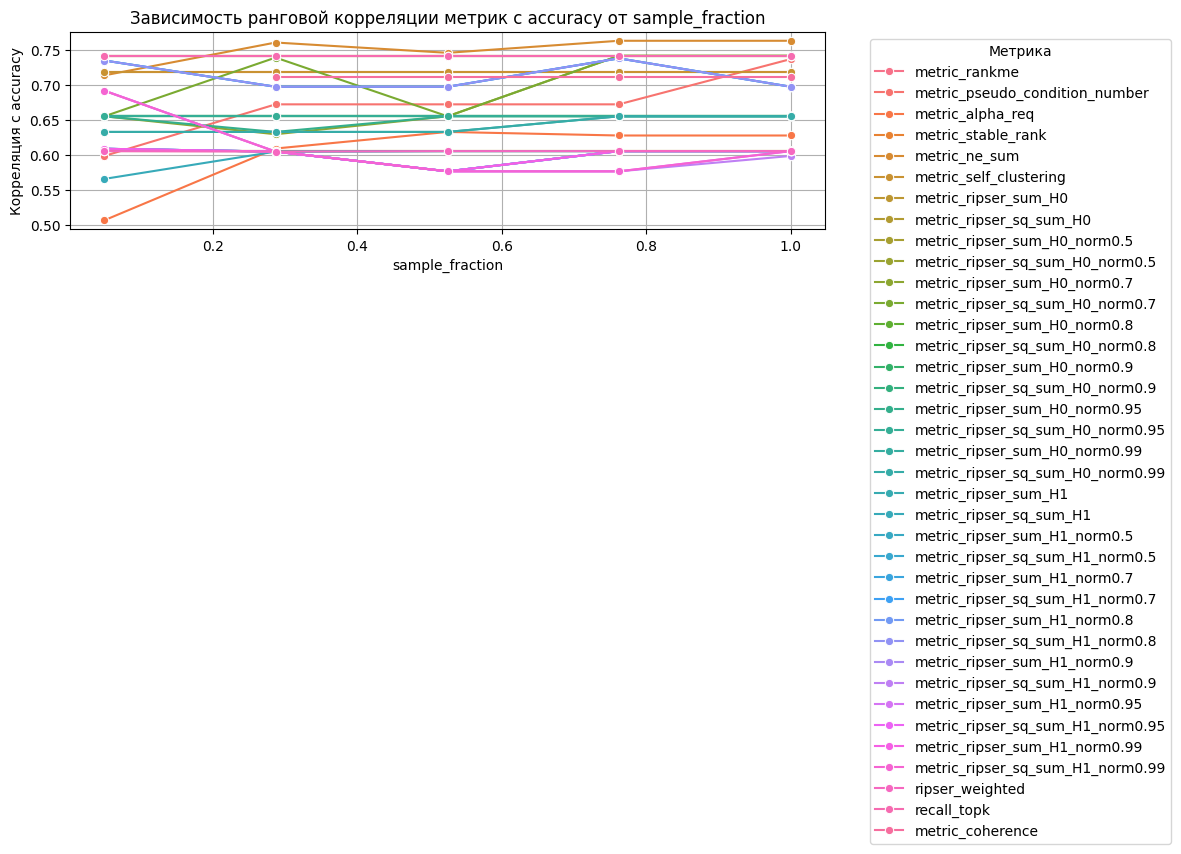

split_count


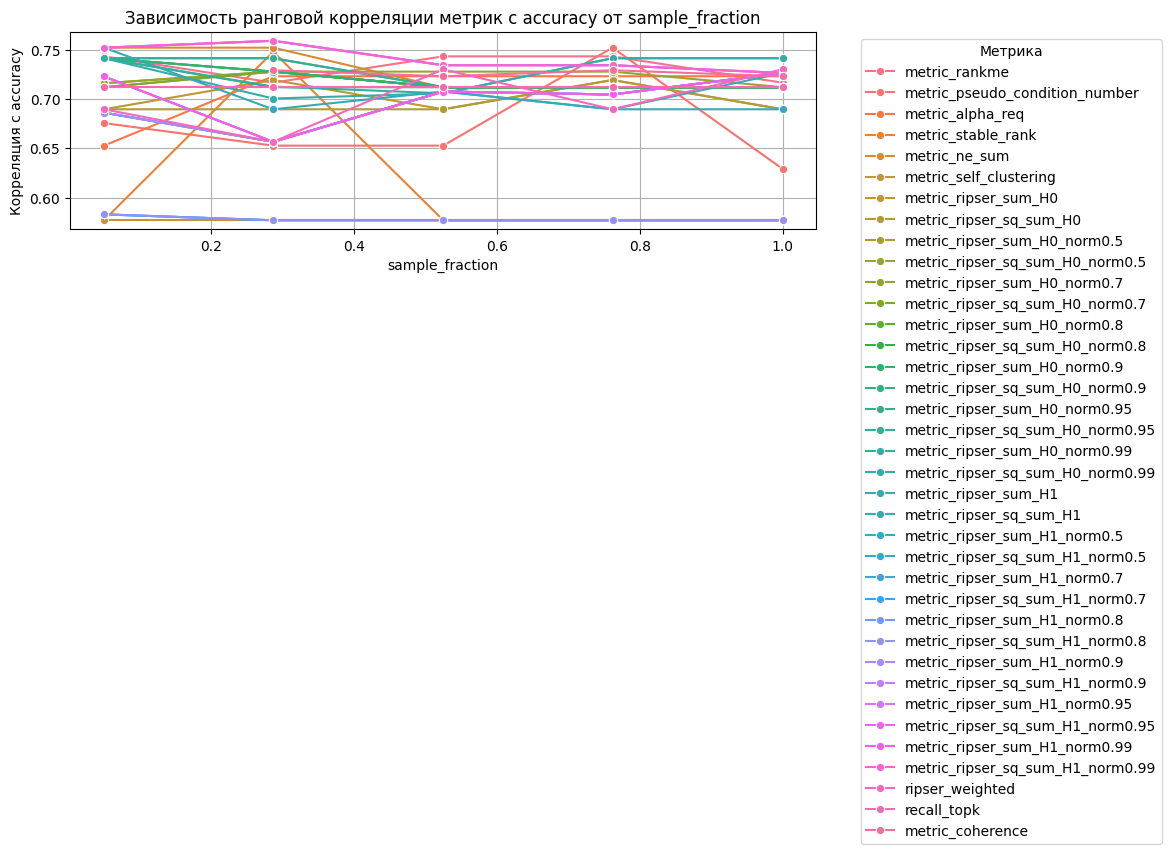

cnt_min


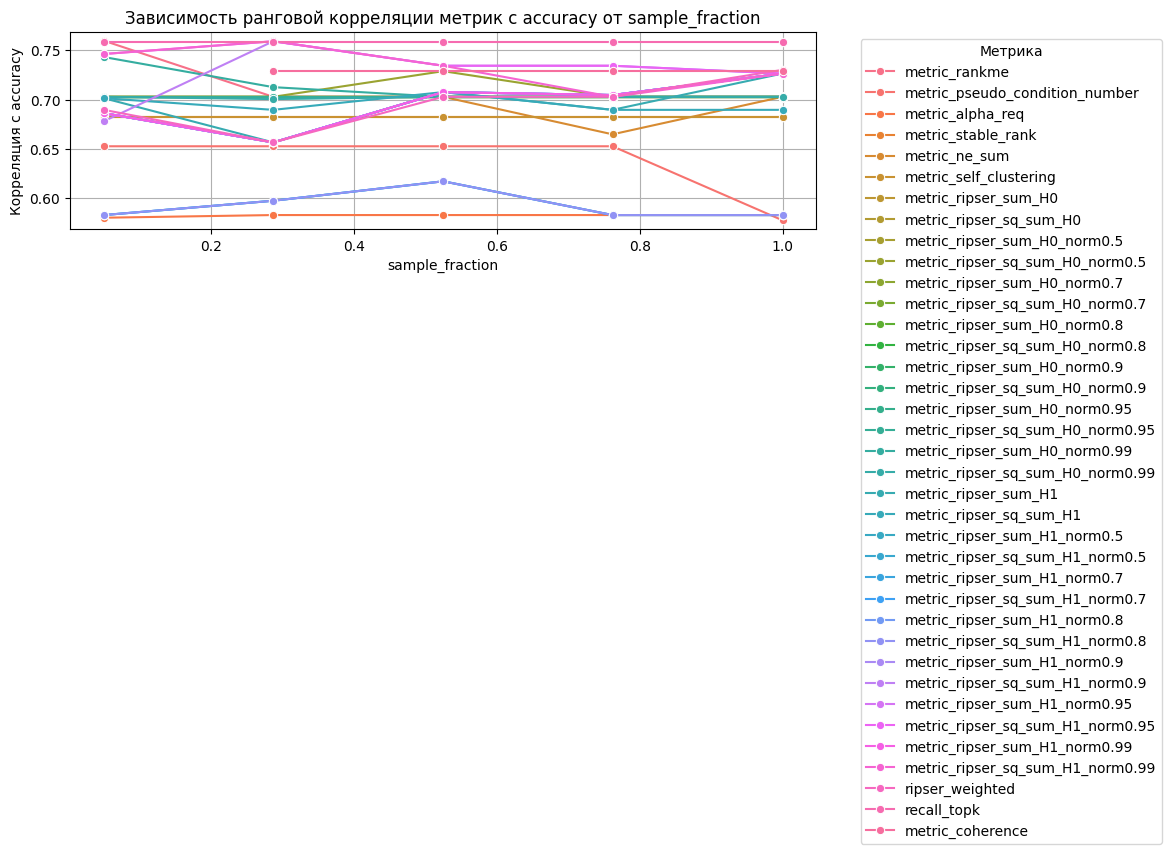

cnt_max


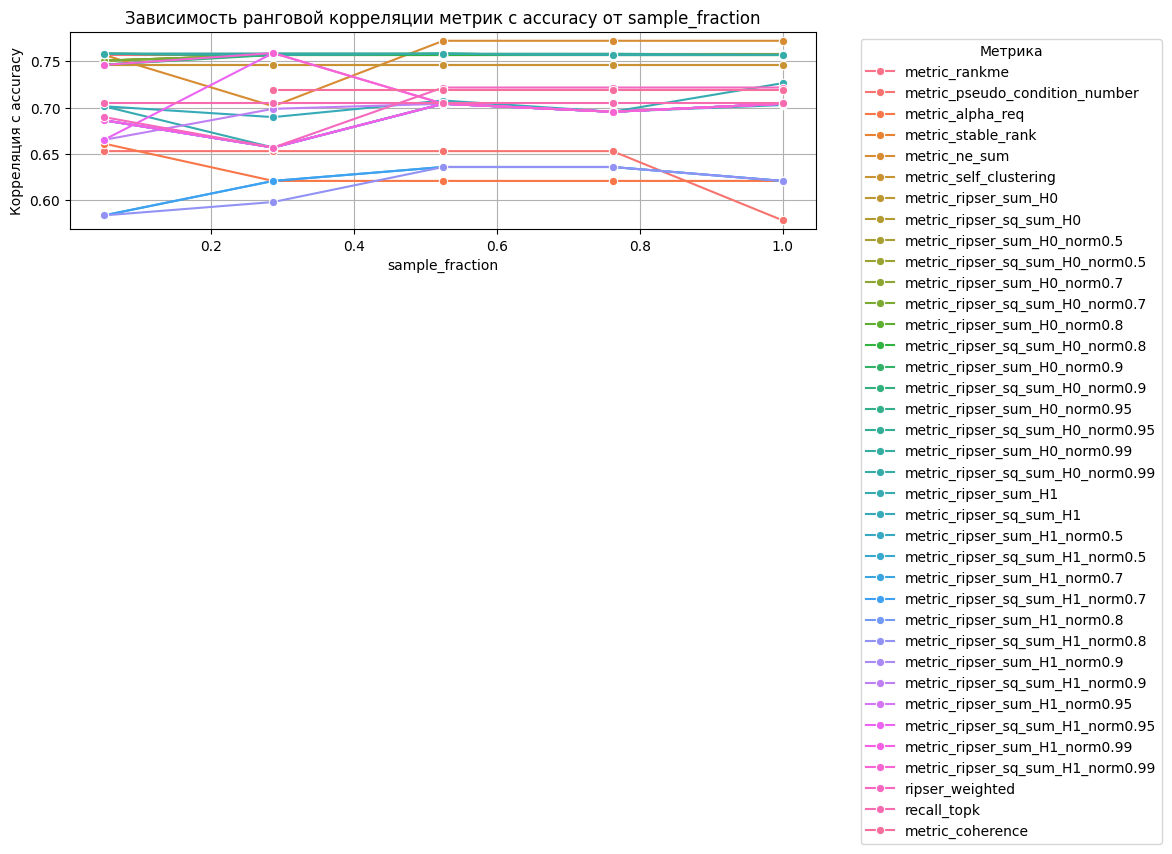

embedding_dim


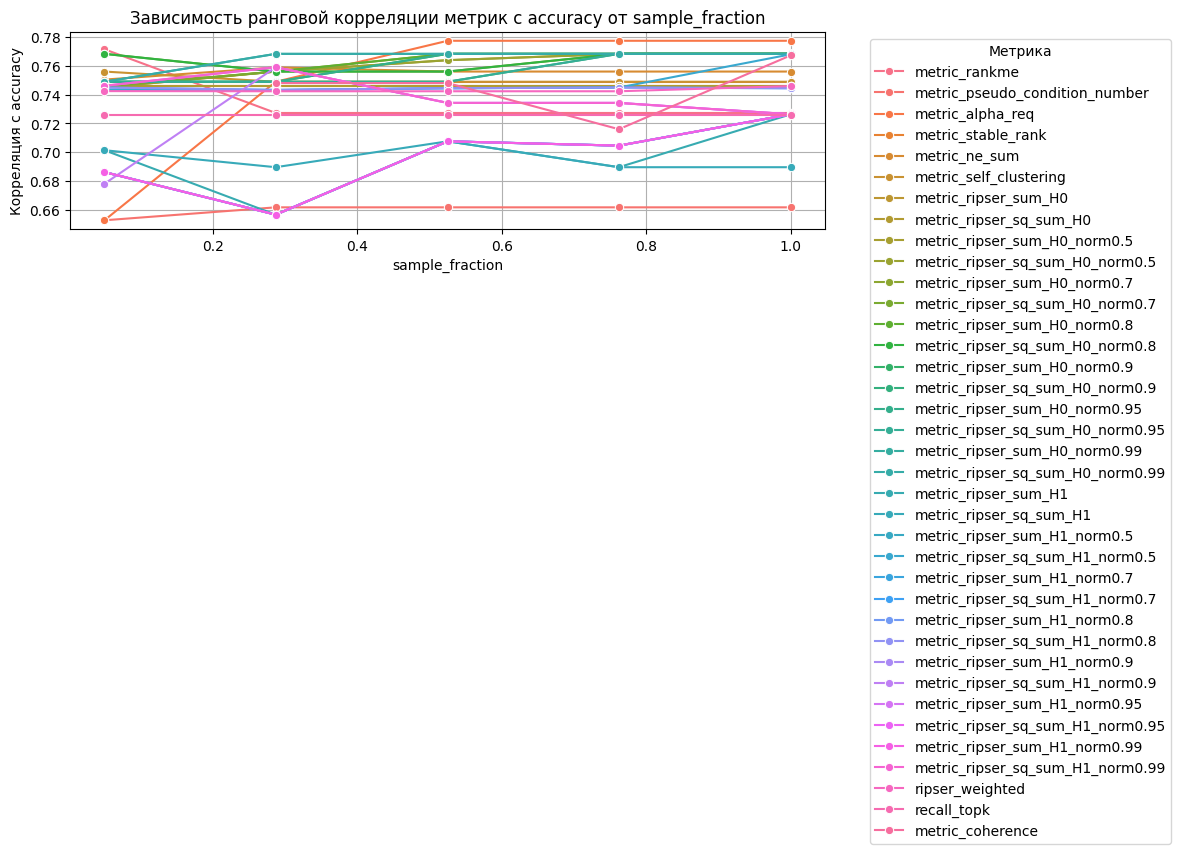

category_embedding_dim


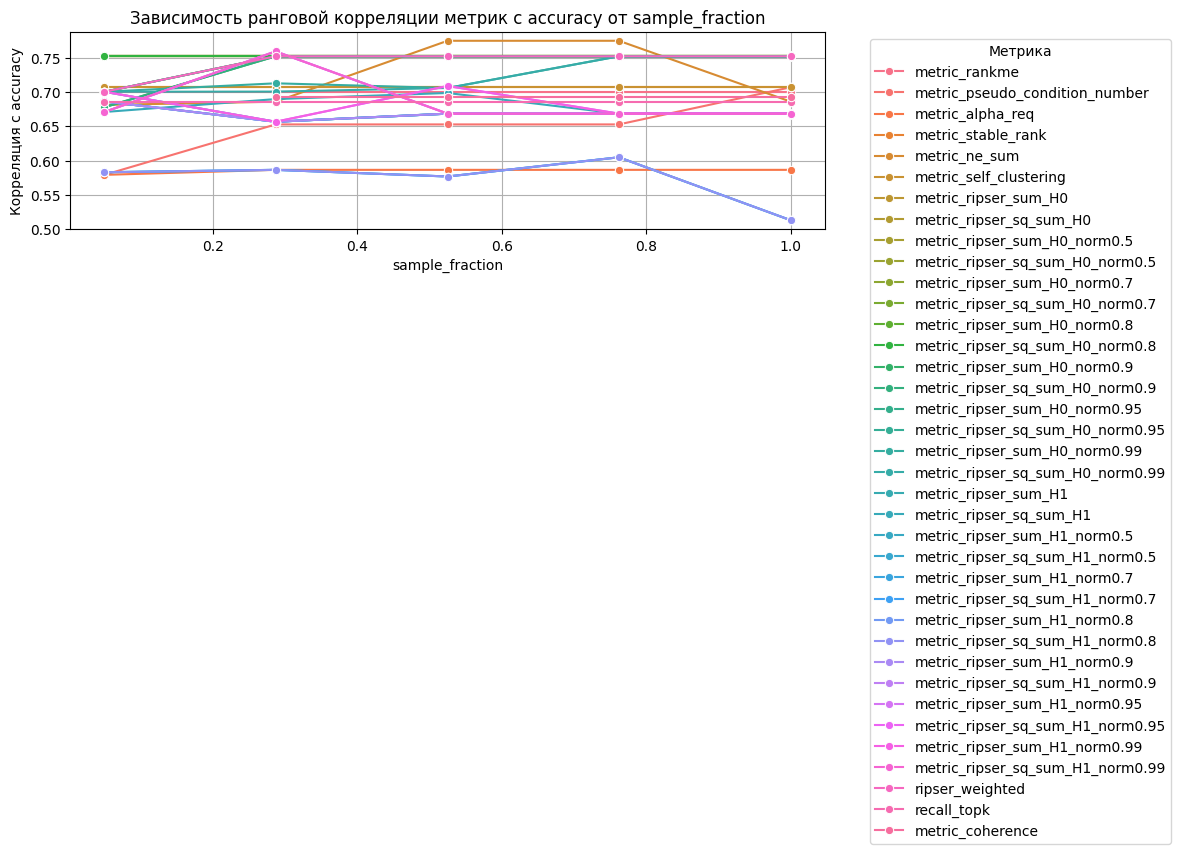

hidden_size


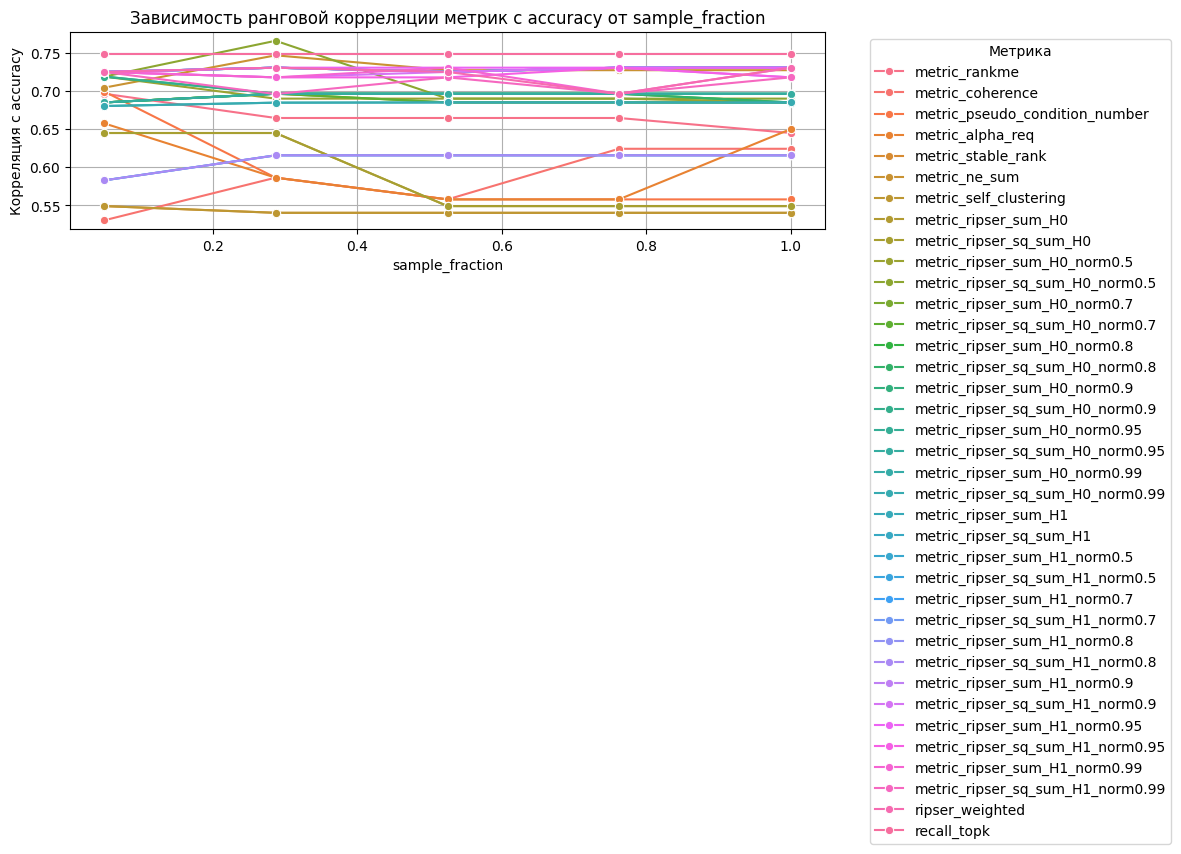

mcc_code_in


ValueError: Could not interpret value `sample_fraction` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

In [25]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [26]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    print (corr_df)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    
        print(mean_corr)

batch_size
     sample_fraction                            metric     auc
0               0.05                     metric_rankme  0.7329
1               0.05    metric_pseudo_condition_number  0.5438
2               0.05                  metric_alpha_req  0.6527
3               0.05                metric_stable_rank  0.7088
4               0.05                     metric_ne_sum  0.7046
..               ...                               ...     ...
179             1.00  metric_ripser_sq_sum_H1_norm0.95  0.7394
180             1.00     metric_ripser_sum_H1_norm0.99  0.7264
181             1.00  metric_ripser_sq_sum_H1_norm0.99  0.7394
182             1.00                   ripser_weighted  0.7301
183             1.00                       recall_topk  0.7628

[184 rows x 3 columns]
metric
recall_topk                         0.76280
metric_ripser_sq_sum_H1_norm0.99    0.74925
metric_ripser_sq_sum_H1_norm0.95    0.73995
metric_rankme                       0.73290
metric_ripser_sq_sum_H0_no

In [27]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    if corr_df.shape[0]:
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)

        print(mean_corr)

batch_size
metric
metric_ne_sum                       0.7724
recall_topk                         0.7628
metric_alpha_req                    0.7560
metric_pseudo_condition_number      0.7460
metric_ripser_sq_sum_H1_norm0.95    0.7394
metric_ripser_sq_sum_H1_norm0.9     0.7394
metric_ripser_sq_sum_H1_norm0.99    0.7394
metric_rankme                       0.7329
ripser_weighted                     0.7301
metric_coherence                    0.7292
metric_ripser_sum_H1_norm0.5        0.7264
metric_ripser_sum_H1_norm0.7        0.7264
metric_ripser_sum_H1_norm0.9        0.7264
metric_ripser_sum_H1_norm0.99       0.7264
metric_ripser_sum_H1                0.7264
metric_ripser_sum_H1_norm0.8        0.7264
metric_ripser_sum_H1_norm0.95       0.7264
metric_ripser_sum_H0_norm0.5        0.7207
metric_ripser_sq_sum_H0_norm0.7     0.7207
metric_ripser_sum_H0_norm0.7        0.7207
metric_ripser_sq_sum_H0_norm0.5     0.7207
metric_stable_rank                  0.7088
metric_self_clustering              

In [28]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    if (corr_df.shape[0]):
        mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
        print(param)
        print(mean_corr)

batch_size
metric
recall_topk                         0.76280
metric_ne_sum                       0.74464
metric_ripser_sq_sum_H1_norm0.99    0.74334
metric_ripser_sq_sum_H1_norm0.95    0.73962
metric_alpha_req                    0.73534
metric_ripser_sq_sum_H1_norm0.9     0.73506
metric_rankme                       0.73290
metric_coherence                    0.72920
metric_ripser_sq_sum_H0_norm0.5     0.72830
metric_ripser_sum_H0_norm0.5        0.72668
metric_ripser_sq_sum_H0_norm0.7     0.72416
metric_ripser_sum_H0_norm0.7        0.71910
metric_ripser_sum_H0_norm0.99       0.71732
metric_ripser_sq_sum_H0_norm0.8     0.71658
metric_ripser_sq_sum_H0_norm0.99    0.71490
metric_ripser_sum_H0_norm0.95       0.71462
metric_ripser_sq_sum_H0_norm0.95    0.71462
metric_ripser_sum_H0_norm0.8        0.71442
metric_ripser_sq_sum_H0_norm0.9     0.71442
metric_pseudo_condition_number      0.70996
metric_self_clustering              0.70880
metric_stable_rank                  0.70880
metric_ripser_

In [74]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

# Standard deviation of score of best param selection

In [43]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


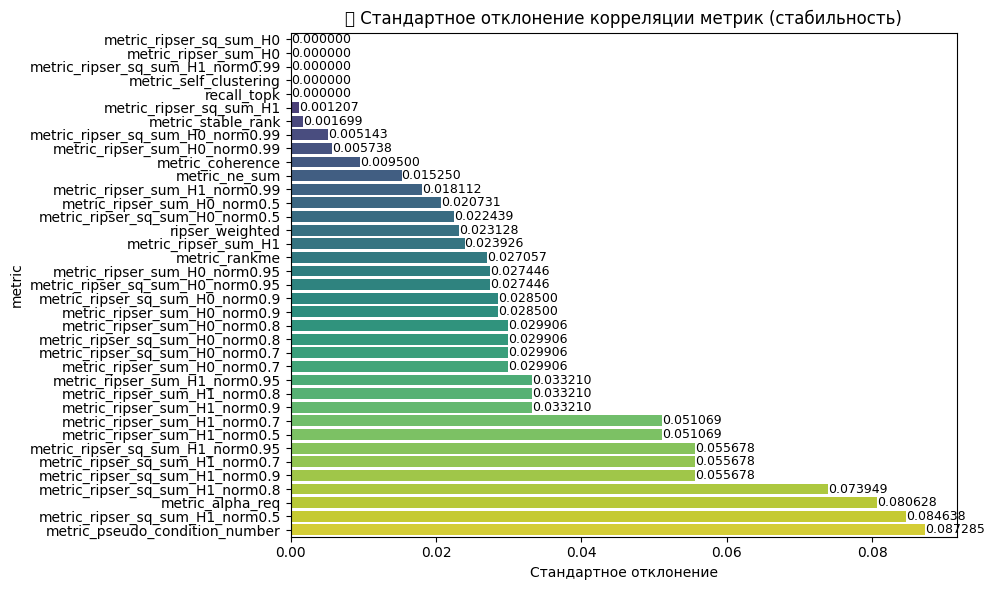

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


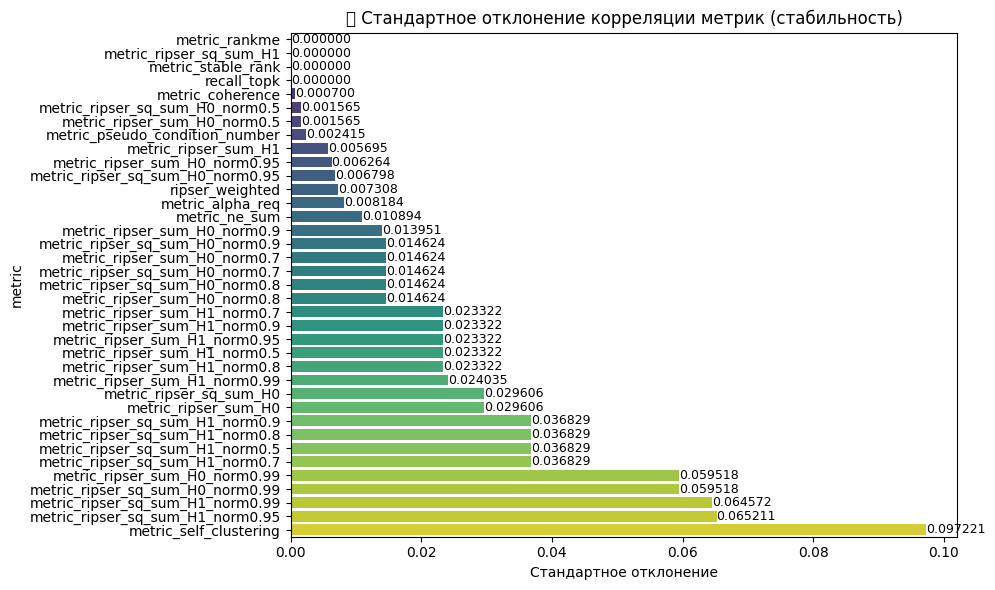

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


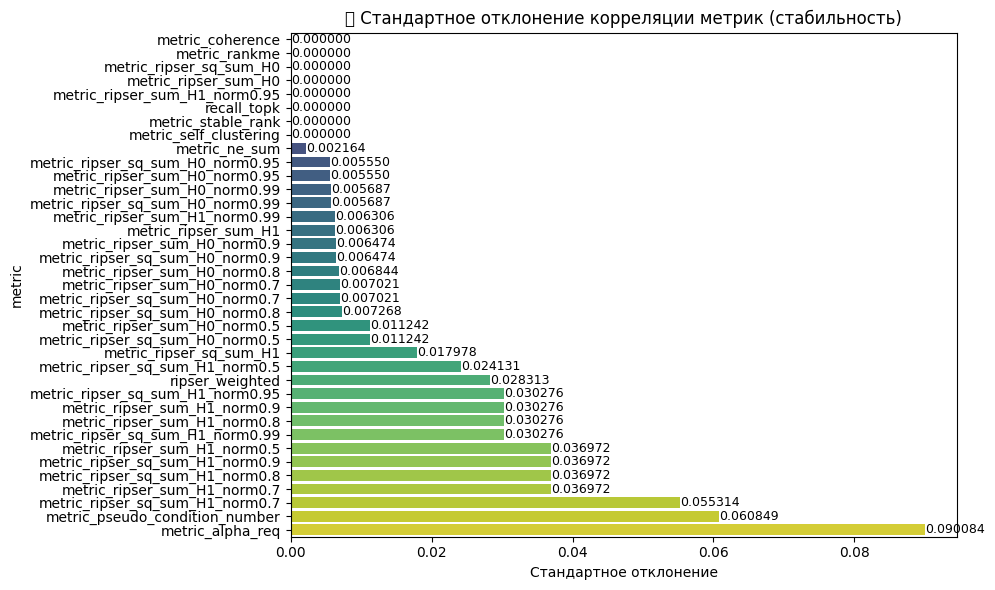

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


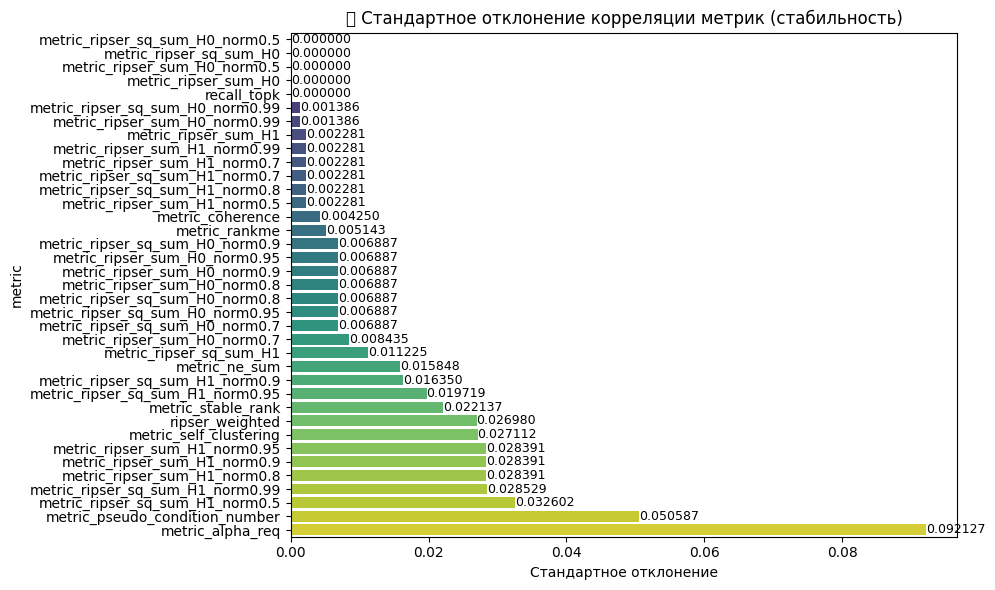

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


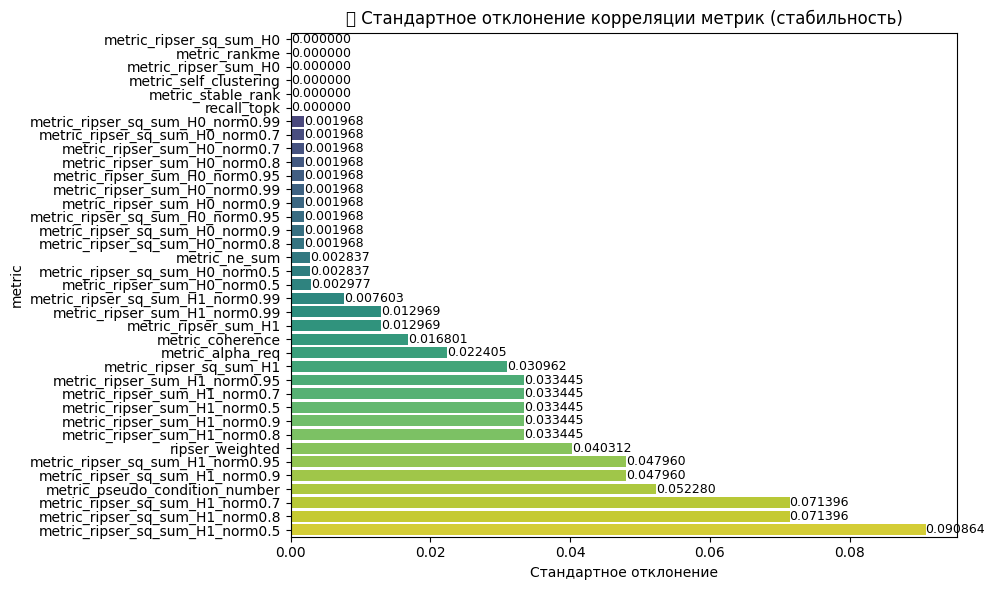

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


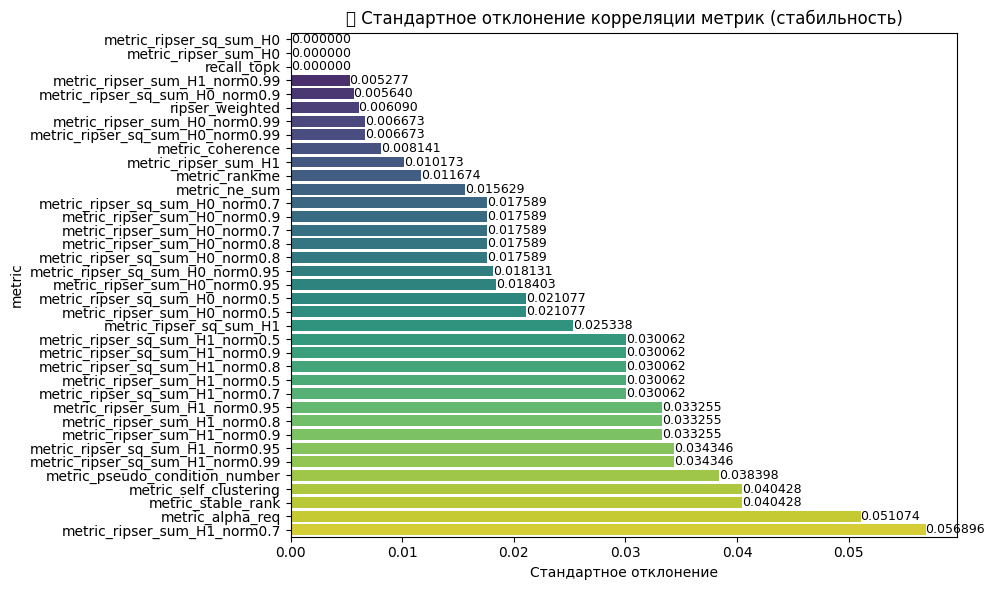

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


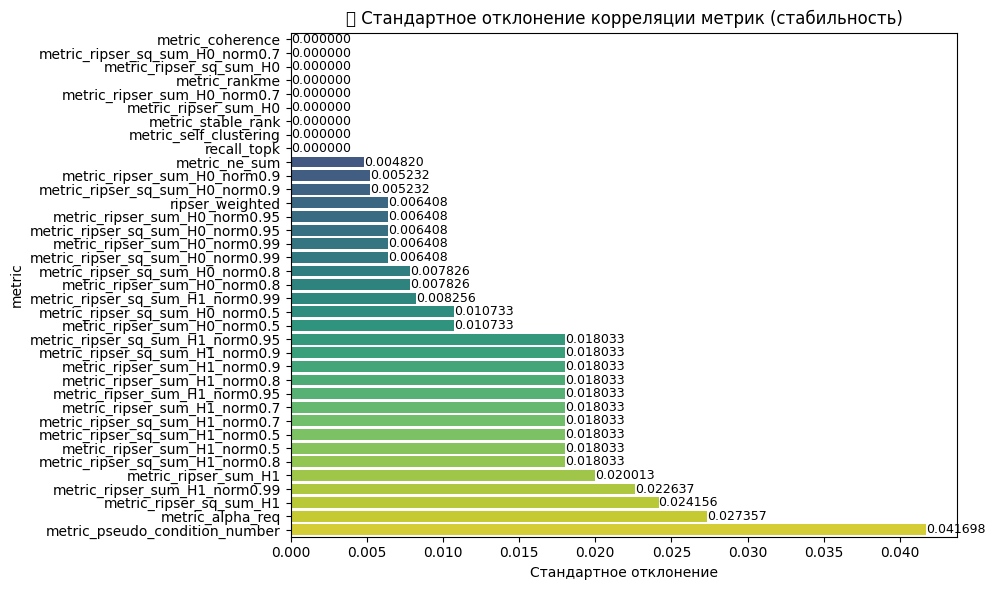

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


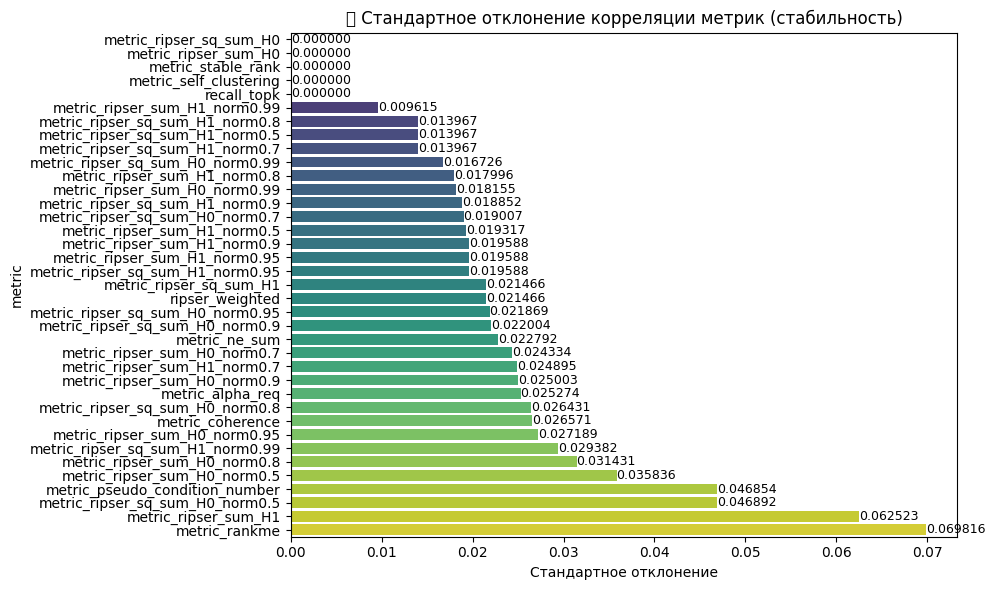

In [45]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()